In [1]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

In [4]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2010-2021_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2010, 2011, 2018, 2019, 2020, 


In [5]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2022_Cases_Dates.txt", "r")
print(f.read())

months: 7, 8, 9, 10, 
years: 2022, 


In [6]:
r_u = 0.01
near_u = 0.05
smote = 0.2
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
features_to_remove = []
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2022.csv'

In [7]:
dataset = read_data(path, drop_columns = features_to_remove, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.761054,39.691860,2010-01-01,θεσσαλιας,αγιας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,661.8,10705.0,17.3,45.75488,0.334542,0.076456,-0.204286,-0.076456,0.150538,0.30311,0.239247,-0.30311,0.014625,0.025915,0.041455,0.025915,12.997875,16.053750,9.942,11.109776,4.927014,9.632237,3.969790,16.854539,5.921401,19.326126,8.137993,0.031663,0.031663,0.031663,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,10,0,0
1,22.726710,39.125600,2010-01-01,θεσσαλιας,αλμυρου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,905.4,16004.0,20.6,45.24728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.189792,16.729583,9.650,9.988979,4.453562,11.092001,4.085860,17.402407,6.040758,21.116459,7.973342,0.189728,0.189728,0.189728,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,1,0,0
2,23.998420,39.245850,2010-01-01,θεσσαλιας,αλοννησου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,129.6,3153.0,21.2,46.00175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,1,0,0
3,21.485102,39.296296,2010-01-01,θεσσαλιας,αργιθεας,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,372.9,3515.0,9.3,44.78625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.566179,1.498538,4.730211,-1.121905,12.474595,1.872899,17.555363,5.933300,48.433745,48.433745,48.433745,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393,22,71,20,71.0,20,71,9,9,4,1,1,2,0,30,0,0
4,22.935020,39.381170,2010-01-01,θεσσαλιας,βολου,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,385.6,138865.0,374.6,45.57293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.258333,NaN,12.890946,4.615169,12.072094,3.769438,17.947073,5.979803,22.062576,8.213274,0.003329,0.003329,0.003329,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,1,0,0


In [8]:
dataset = dataset.query('month >= 5 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [9]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.761054,39.691860,2010-05-01,θεσσαλιας,αγιας,1,5,17,2010,0.201299,0.979530,0.5,-8.660254e-01,0.902798,-0.430065,661.8,10705.0,17.3,45.75488,0.534072,0.227123,-0.275322,-0.227123,0.532820,0.232493,-0.266338,-0.232493,0.038192,0.038160,0.031002,0.038160,17.916875,23.528125,12.305625,11.109776,4.927014,9.632237,3.969790,16.854539,5.921401,19.326126,8.137993,2.085057,37.142217,454.301021,8282.127022,1331.619869,1,123.585589,121.767859,183.036108,0.0,21.311709,22,76,20,76.0,20,76,9,9,4,2,2,2,0,6,14,0
1,22.726710,39.125600,2010-05-01,θεσσαλιας,αλμυρου,1,5,17,2010,0.201299,0.979530,0.5,-8.660254e-01,0.902798,-0.430065,905.4,16004.0,20.6,45.24728,0.505125,0.172119,-0.311227,-0.172119,0.502747,0.165386,-0.316192,-0.165386,0.045203,0.049454,0.029783,0.049454,18.845625,26.066667,11.624583,9.988979,4.453562,11.092001,4.085860,17.402407,6.040758,21.116459,7.973342,5.390692,20.039047,456.768148,10017.207897,1610.666116,14,259.585198,342.571837,171.163634,0.0,3.415750,21,78,20,78.0,20,78,8,8,4,1,1,2,0,6,9,0
2,23.998420,39.245850,2010-05-01,θεσσαλιας,αλοννησου,1,5,17,2010,0.201299,0.979530,0.5,-8.660254e-01,0.902798,-0.430065,129.6,3153.0,21.2,46.00175,-0.136478,0.183484,0.443938,-0.183484,-0.125642,0.198068,0.454128,-0.198068,0.012114,0.027284,0.023679,0.027284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.618809,33.228392,582.533827,1484.683259,55302.082778,24,302.637680,165.397106,195.027810,0.0,1.676994,21,93,20,93.0,20,93,8,8,4,1,1,2,0,3,2,0
3,21.485102,39.296296,2010-05-01,θεσσαλιας,αργιθεας,1,5,17,2010,0.201299,0.979530,0.5,-8.660254e-01,0.902798,-0.430065,372.9,3515.0,9.3,44.78625,0.486530,0.160200,-0.301230,-0.160200,0.488939,0.162746,-0.298806,-0.162746,0.063066,0.062550,0.048009,0.062550,16.406154,22.280769,10.531538,-0.566179,1.498538,4.730211,-1.121905,12.474595,1.872899,17.555363,5.933300,0.250056,47.746955,808.937265,19327.278832,1925.318354,27,284.268894,1127.254453,234.678996,0.0,1.719393,22,71,20,71.0,20,71,9,9,4,1,1,2,0,8,22,0
4,22.935020,39.381170,2010-05-01,θεσσαλιας,βολου,1,5,17,2010,0.201299,0.979530,0.5,-8.660254e-01,0.902798,-0.430065,385.6,138865.0,374.6,45.57293,0.439090,0.147357,-0.269037,-0.147357,0.441865,0.123027,-0.307204,-0.123027,0.039932,0.034662,0.032236,0.034662,19.485833,26.826667,12.145000,12.890946,4.615169,12.072094,3.769438,17.947073,5.979803,22.062576,8.213274,7.578191,26.653751,450.719562,5935.142744,3071.988689,5,143.181190,234.931813,174.426021,0.0,4.643743,31,95,30,95.0,30,95,10,10,1,6,6,2,0,6,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3956,22.341069,39.610479,2022-09-16,θεσσαλιας,λαρισαιων,16,9,37,2022,-0.101168,-0.994869,-1.0,-1.836970e-16,-0.947326,-0.320270,336.0,164381.0,483.9,45.47651,0.250947,-0.116101,-0.283557,0.116101,0.252444,-0.116519,-0.282682,0.116519,0.056709,0.049903,0.041772,0.049903,28.568889,37.418889,19.718889,10.700565,-1.301608,15.631945,1.035034,18.026641,0.634315,27.226818,8.812485,0.000000,30.605289,955.247184,23891.011963,2476.945317,2,236.748543,113.391504,185.096054,0.0,6.81

In [10]:
dataset['lau1'].unique().shape

(25,)

In [11]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,294,9,303,7.65%
1,2011,277,30,307,7.75%
2,2012,300,0,300,7.57%
3,2013,300,0,300,7.57%
4,2014,300,0,300,7.57%
5,2015,300,0,300,7.57%
6,2016,300,0,300,7.57%
7,2017,300,0,300,7.57%
8,2018,295,7,302,7.62%
9,2019,270,53,323,8.15%


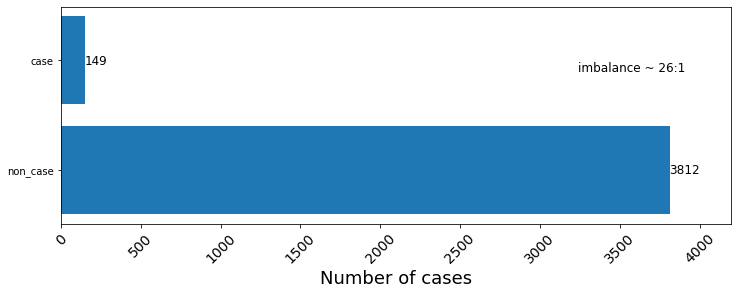

In [12]:
plot_imbalance(dataset)

In [13]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [14]:
years_to_remove = [year for year in range(2012, 2018)]
years_to_remove.append(2021)

for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    X_train.drop(columns = ['day', 'month', 'week', 'year'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer, nm, sm = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    w0,w1 = calculate_weights(y_train)
    w1 = w1*1

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

1515
Year: 2010 || w0:1, w1:9 || ##
1505
Year: 2011 || w0:1, w1:10 || ##
1804
Year: 2012 || w0:1, w1:10 || ##
1804
Year: 2013 || w0:1, w1:10 || ##
1804
Year: 2014 || w0:1, w1:10 || ##
1804
Year: 2015 || w0:1, w1:10 || ##
1804
Year: 2016 || w0:1, w1:10 || ##
1804
Year: 2017 || w0:1, w1:10 || ##
1516
Year: 2018 || w0:1, w1:8 || ##
1484
Year: 2019 || w0:1, w1:12 || ##
1516
Year: 2020 || w0:1, w1:9 || ##
1804
Year: 2021 || w0:1, w1:10 || ##
1485
Year: 2022 || w0:1, w1:11 || ##


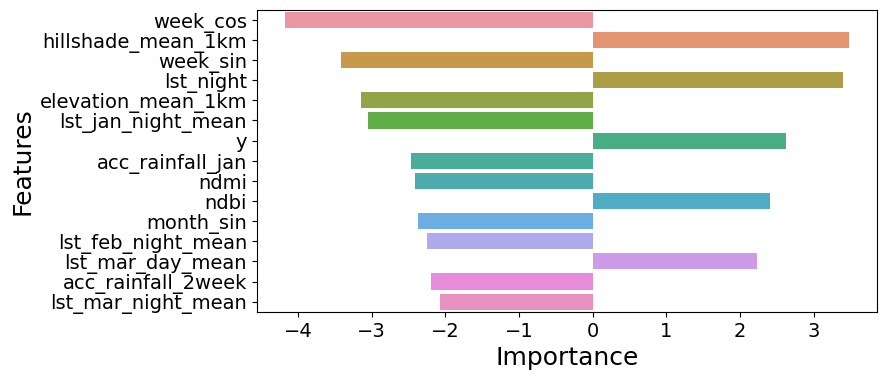

In [15]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

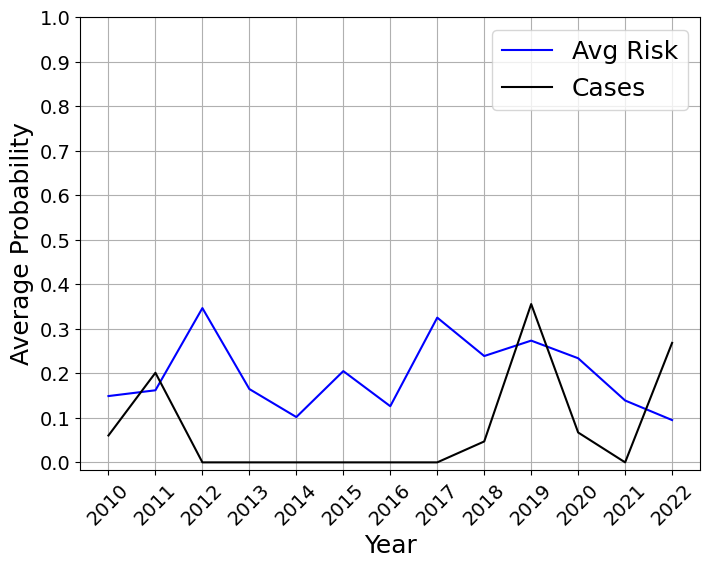

In [16]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

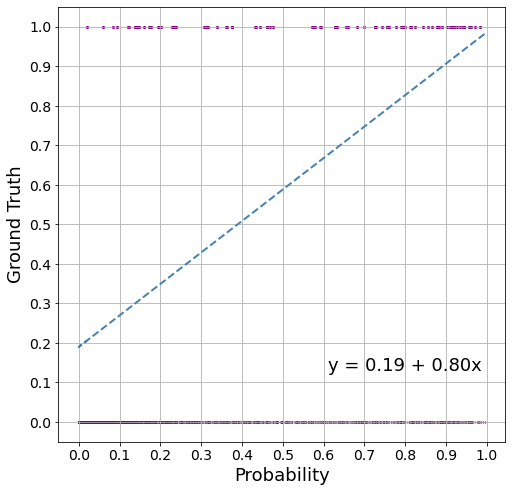

In [17]:
plot_probability_curve(results_test)

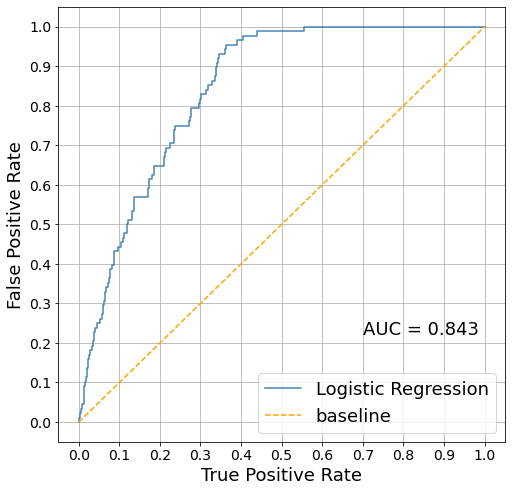

In [18]:
plot_roc_curve(results_test)

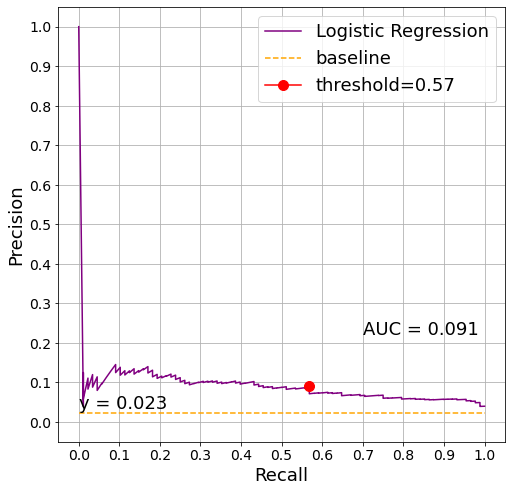

In [19]:
plot_pr_curve(results_test, plot_fbeta = True)

In [20]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 5, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 48.13%
Weighted Average: 54.87%

Random Average: 22.61%
Random Weighted Average: 24.00%


In [21]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/05/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/05/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
3,16/06/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
4,01/07/2010,0,0,0.00,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
151,16/08/2022,4,2,0.82,4,50.00 %,0.5000,20.50 %,0.2050
152,01/09/2022,2,1,0.55,2,50.00 %,0.5000,27.50 %,0.2750
153,16/09/2022,4,1,0.85,4,25.00 %,0.2500,21.25 %,0.2125
154,01/10/2022,3,1,0.63,3,33.33 %,0.3333,21.00 %,0.2100


In [22]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2010,6,1,1.34,6,16.67 %,0.1667,22.33 %,0.2233
1,2011,23,10,4.49,19,52.63 %,0.5263,23.63 %,0.2363
2,2012,0,0,0.00,0,nan %,NaN,nan %,NaN
3,2013,0,0,0.00,0,nan %,NaN,nan %,NaN
4,2014,0,0,0.00,0,nan %,NaN,nan %,NaN
5,2015,0,0,0.00,0,nan %,NaN,nan %,NaN
6,2016,0,0,0.00,0,nan %,NaN,nan %,NaN
7,2017,0,0,0.00,0,nan %,NaN,nan %,NaN
8,2018,5,4,1.03,5,80.00 %,0.8000,20.60 %,0.2060
9,2019,30,17,6.08,22,77.27 %,0.7727,27.64 %,0.2764


In [23]:
results_test

,x,y,lau1,day,month,year,case,score
0,22.341069,39.610479,λαρισαιων,16,8,2012,0,9.946507e-01
1,22.341069,39.610479,λαρισαιων,16,7,2012,0,9.946129e-01
2,22.341069,39.610479,λαρισαιων,1,8,2012,0,9.919094e-01
3,22.296112,39.762971,τυρναβου,16,8,2012,0,9.903619e-01
4,22.296112,39.762971,τυρναβου,16,7,2012,0,9.863877e-01
...,...,...,...,...,...,...,...,...
3895,23.078003,39.457740,ζαγορας μουρεσιου,1,5,2014,0,5.515077e-07
3896,21.722470,39.303447,λιμνης πλαστηρα,1,5,2016,0,4.610800e-07
3897,23.998420,39.245850,αλοννησου,1,5,2011,0,3.842095e-07
3898,23.998420,39.245850,αλοννησου,1,5,2015,0,2.117345e-07


In [24]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.2, beta = 4)

In [25]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,6.0000,0.2367,0.8044,0.0704,0.8333,0.5090,0.2306
1,2011,23.0000,0.2533,0.7631,0.2237,0.7391,0.6509,0.2692
2,2012,0.0000,0.5000,0.5000,0.0000,0.0000,0.0000,0.8000
3,2013,0.0000,0.2767,0.7233,0.0000,0.0000,0.0000,0.2655
4,2014,0.0000,0.1767,0.8233,0.0000,0.0000,0.0000,0.1452
5,2015,0.0000,0.3500,0.6500,0.0000,0.0000,0.0000,0.3738
6,2016,0.0000,0.2267,0.7733,0.0000,0.0000,0.0000,0.1838
7,2017,0.0000,0.4600,0.5400,0.0000,0.0000,0.0000,0.6514
8,2018,5.0000,0.3667,0.7203,0.0364,0.8000,0.3579,0.4147
9,2019,30.0000,0.4333,0.7963,0.2231,0.9667,0.8082,0.3896


In [26]:
results_test

,x,y,lau1,day,month,year,case,score
0,22.341069,39.610479,λαρισαιων,16,8,2012,0,9.946507e-01
1,22.341069,39.610479,λαρισαιων,16,7,2012,0,9.946129e-01
2,22.341069,39.610479,λαρισαιων,1,8,2012,0,9.919094e-01
3,22.296112,39.762971,τυρναβου,16,8,2012,0,9.903619e-01
4,22.296112,39.762971,τυρναβου,16,7,2012,0,9.863877e-01
...,...,...,...,...,...,...,...,...
3895,23.078003,39.457740,ζαγορας μουρεσιου,1,5,2014,0,5.515077e-07
3896,21.722470,39.303447,λιμνης πλαστηρα,1,5,2016,0,4.610800e-07
3897,23.998420,39.245850,αλοννησου,1,5,2011,0,3.842095e-07
3898,23.998420,39.245850,αλοννησου,1,5,2015,0,2.117345e-07


In [27]:
results_test[['x', 'y', 'day', 'month', 'year']].value_counts()

x          y          day  month  year
21.428661  39.481416  1    5      2010    1
22.726710  39.125600  16   8      2017    1
                           6      2015    1
                                  2016    1
                                  2017    1
                                         ..
22.089952  39.240481  1    9      2014    1
                                  2015    1
                                  2016    1
                                  2017    1
23.998420  39.245850  16   10     2022    1
Length: 3900, dtype: int64

In [28]:
results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [29]:
scalers = {'minmax': MinMaxScaler(),
               'standard': StandardScaler(),
               'robust': RobustScaler(),
               'abs': MaxAbsScaler()}

data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
X_train.drop(columns = ['day', 'month', 'week', 'year'])
y_train = data_train['case']

if(r_u != 0):
    nan_index = []
    zero_index = []
        
    for index, row in X_train.iterrows():
        if row.isnull().values.any():
            nan_index.append(index)
            if y_train.iloc[index] == 0:
                zero_index.append(index)
            
    nan_set = set(nan_index)
    zero_set = set(zero_index)
        
    intersection = list(nan_set.intersection(zero_set))
    sampling_size = math.ceil(len(intersection) * r_u)
    removed = random.sample(intersection, sampling_size)
        
    X_train = X_train.drop(index = removed, axis = 1)
    y_train = y_train.drop(index = removed, axis = 1)

scaler = scalers.get(scaler, MinMaxScaler())
X_train = scaler.fit_transform(X_train)
    
imputer = KNNImputer()
X_train = imputer.fit_transform(X_train)

try:
    class_0_counts = y_train.value_counts()[0]
except KeyError:
    class_0_counts = 0
try:
    class_1_counts = y_train.value_counts()[1]
except KeyError:
    class_1_counts = 0

if (near_u != 0):
    nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    X_train, y_train = nm.fit_resample(X_train, y_train)

if (smote != 0):
    class_0_counts = y_train.value_counts()[0]
    sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    X_train, y_train = sm.fit_resample(X_train, y_train)

In [30]:
trained_model = train_lin_model(model, X_train, y_train)

In [31]:
trained_model

LogisticRegression(class_weight={0.0: 1, 1.0: 11}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [32]:
pickle.dump(trained_model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model.pkl', 'wb'))